### 1-Importaciones


In [363]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### 2-Carga de datos

In [364]:
df = pd.read_csv('/workspaces/Elreno23-machine-learning-python-template/data/raw/03-linear-regression-reg-demographic-health-data.csv')
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


### 3-Exploración Inicial

In [365]:
null = df.isna().sum()
print(null[null > 0])
df.info()
df.describe()
df.columns

Series([], dtype: int64)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


Index(['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct',
       '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop',
       '30-39', '30-39 y/o % of total pop',
       ...
       'COPD_number', 'diabetes_prevalence', 'diabetes_Lower 95% CI',
       'diabetes_Upper 95% CI', 'diabetes_number', 'CKD_prevalence',
       'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
       'Urban_rural_code'],
      dtype='object', length=108)

In [ ]:
cols = df.columns.to_list()
for i in range(0, len(cols), 20):
    print(cols[i:i+20])

df = df.drop(columns=[
    "fips","STATE_FIPS","CNTY_FIPS","COUNTY_NAME","STATE_NAME","Urban_rural_code",
    "Total Population",
    "0-9","0-9 y/o % of total pop",
    "10-19 y/o % of total pop",
    "20-29","20-29 y/o % of total pop",
    "30-39","30-39 y/o % of total pop",
    "40-49","40-49 y/o % of total pop",
    "50-59","50-59 y/o % of total pop",
    "60-69","60-69 y/o % of total pop",
    "70-79","70-79 y/o % of total pop",
    "80+","80+ y/o % of total pop",
    "White-alone pop","% White-alone",
    "Black-alone pop","% Black-alone",
    "Native American/American Indian-alone pop","% NA/AI-alone",
    "Asian-alone pop","% Asian-alone",
    "Hawaiian/Pacific Islander-alone pop","% Hawaiian/PI-alone",
    "Two or more races pop","% Two or more races",
    "Obesity_Lower 95% CI","Obesity_Upper 95% CI",
    "Heart disease_Lower 95% CI","Heart disease_Upper 95% CI",
    "COPD_Lower 95% CI","COPD_Upper 95% CI",
    "diabetes_Lower 95% CI","diabetes_Upper 95% CI",
    "CKD_Lower 95% CI","CKD_Upper 95% CI",
    "CI90LBINC_2018","CI90UBINC_2018",
    "anycondition_prevalence","anycondition_number",
    "Med_HH_Income_Percent_of_State_Total_2018",
    "Internal Medicine Primary Care (2019)",
    "Family Medicine/General Practice Primary Care (2019)",
    "Total Specialist Physicians (2019)"])

df = df.drop_duplicates()
df.isna().sum().any()
df.shape

df = df.drop(columns=["Median_Household_Income_2018","POP_ESTIMATE_2018","ICU Beds_x","GQ_ESTIMATES_2018","19-Oct","R_birth_2018", "R_death_2018", "R_NATURAL_INC_2018", "R_INTERNATIONAL_MIG_2018", "R_DOMESTIC_MIG_2018", "R_NET_MIG_2018", "anycondition_Lower 95% CI", "anycondition_Upper 95% CI"])
df_int = df.select_dtypes(include="int").columns
df_float = df.select_dtypes(include="float").columns
df_object = df.select_dtypes(include="object").columns
(df[df_int] == 0).sum().head(27)
(df[df_float] == 0).sum().head(27)
df.isna().sum().any()
df.nunique().head(22)
df.nunique().tail(21)

df[df_int].describe().T
df[df_float].describe().T


['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct', '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop', '30-39', '30-39 y/o % of total pop', '40-49', '40-49 y/o % of total pop', '50-59', '50-59 y/o % of total pop', '60-69', '60-69 y/o % of total pop', '70-79', '70-79 y/o % of total pop', '80+', '80+ y/o % of total pop']
['White-alone pop', '% White-alone', 'Black-alone pop', '% Black-alone', 'Native American/American Indian-alone pop', '% NA/AI-alone', 'Asian-alone pop', '% Asian-alone', 'Hawaiian/Pacific Islander-alone pop', '% Hawaiian/PI-alone', 'Two or more races pop', '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018', 'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018', 'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018']
['R_NET_MIG_2018', 'Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", 'Percent of adults with l

""
0
1
2
3
4
...
3135
3136
3137
3138


### 4-Analisis univariado

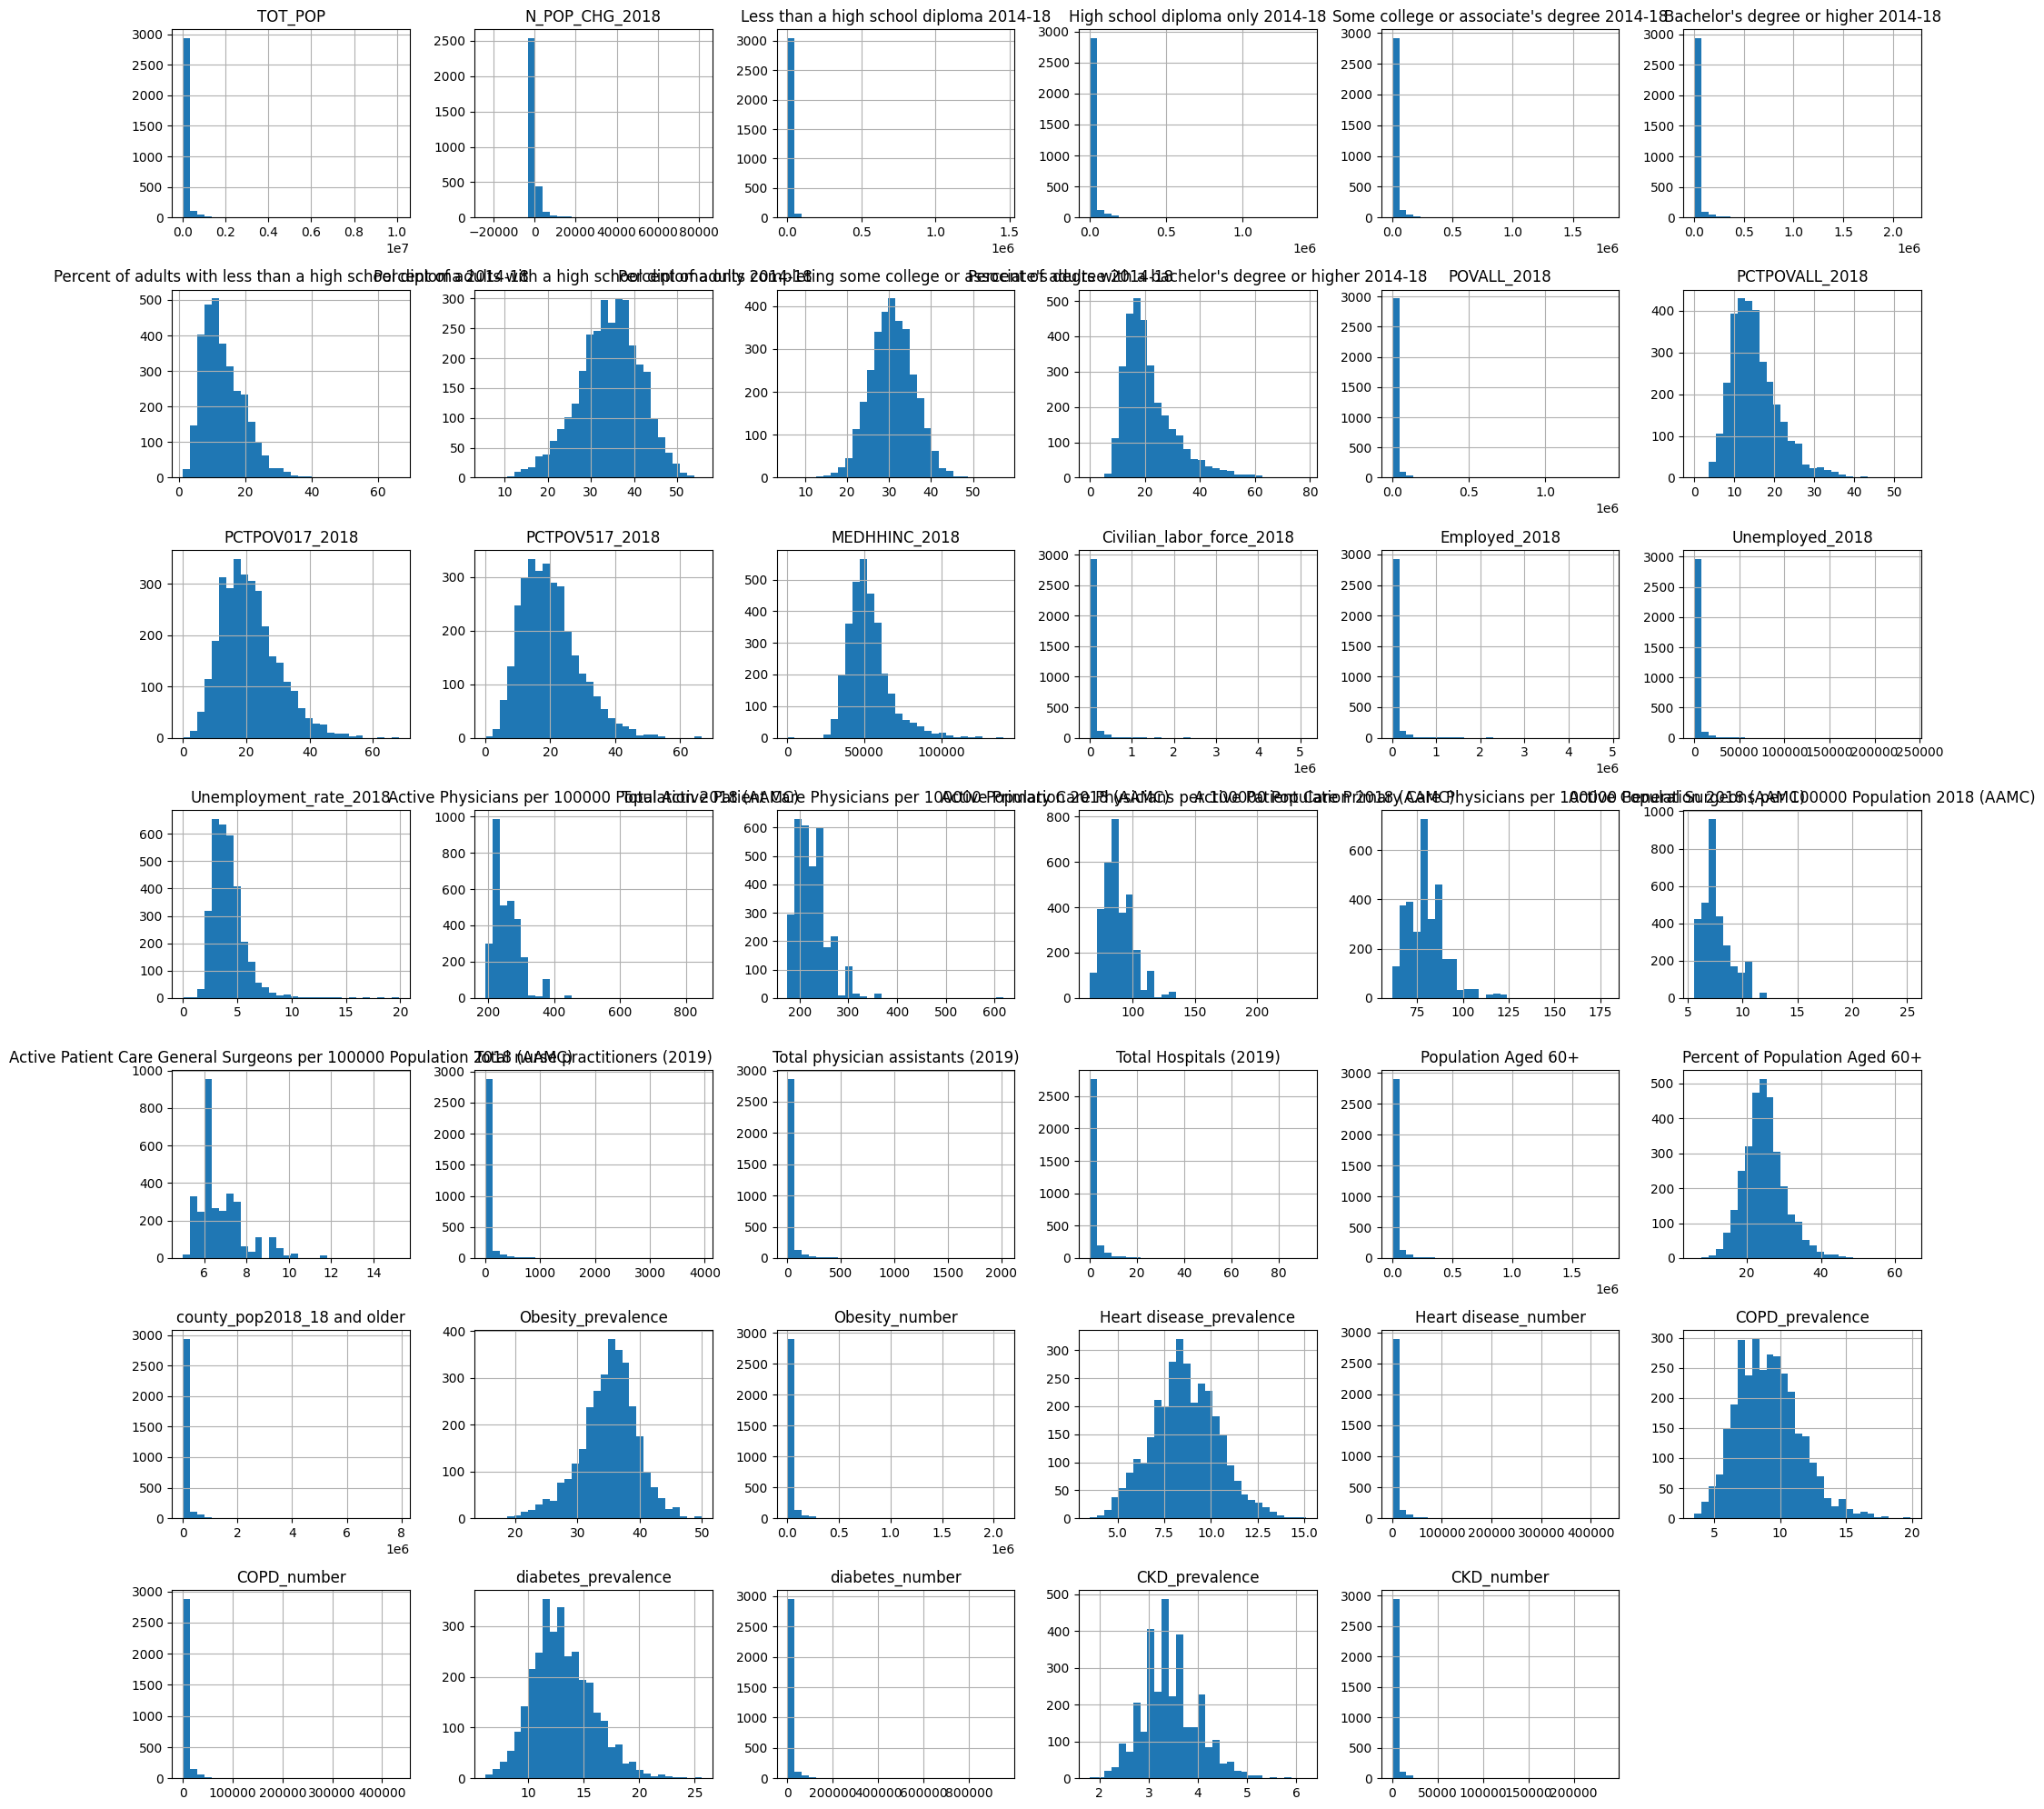

In [367]:
df.hist(figsize=(20,20),bins=30)
plt.tight_layout()
plt.show()